In [1]:
!nvidia-smi

Thu Sep  3 13:22:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Construction Site Safety Monitor.v1i.yolov8.zip to Construction Site Safety Monitor.v1i.yolov8.zip


In [4]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
!find /content/dataset -name "data.yaml" -o -name "data.yml"

/content/dataset/data.yaml


In [6]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/test
/content/dataset/test/labels
/content/dataset/test/images
/content/dataset/train
/content/dataset/train/labels
/content/dataset/train/images
/content/dataset/valid
/content/dataset/valid/labels
/content/dataset/valid/images


In [7]:
print(open("/content/dataset/data.yaml").read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 10
names: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']

roboflow:
  workspace: satwik-prabhu
  project: construction-site-safety-monitor-tdr0d
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/satwik-prabhu/construction-site-safety-monitor-tdr0d/dataset/1


In [8]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 8.3 MB/s eta 0:00:00


In [9]:
import torch
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics version: 8.4.138
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [10]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [11]:
import os

for split in ["train", "valid", "test"]:
    images = len(os.listdir(f"/content/dataset/{split}/images"))
    labels = len(os.listdir(f"/content/dataset/{split}/labels"))
    print(f"{split}: {images} images, {labels} labels")

train: 2599 images, 2599 labels
valid: 104 images, 104 labels
test: 74 images, 74 labels


In [12]:
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    device=0,
    project="/content/runs",
    name="construction_safety_yolo11n"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=construction_safety_yolo11n, nbs=64

In [13]:
#testing with 74 images
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/construction_safety_yolo11n/weights/best.pt"
)

test_metrics = best_model.val(
    data="/content/dataset/data.yaml",
    split="test"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1616.5±748.1 MB/s, size: 64.1 KB)
val: Scanning /content/dataset/test/labels... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 2.0Kit/s 0.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.1it/s 4.5s
                   all         74        760      0.828      0.633      0.699      0.403
               Hardhat         30        110      0.977      0.755      0.852      0.504
                  Mask         16         28          1      0.754      0.785      0.504
            NO-Hardhat         25         41      0.763      0.551      0.463      0.243
               NO-Mask         30         79      0.763      0.506      0.618      0.223

In [14]:
#generate visual predictions
from ultralytics import YOLO

best_model = YOLO(
    "/content/runs/construction_safety_yolo11n/weights/best.pt"
)

prediction_results = best_model.predict(
    source="/content/dataset/test/images",
    conf=0.25,
    save=True
)


image 1/74 /content/dataset/test/images/-4405-_png_jpg.rf.0bdd638fcc8ff7f40912f85737fae8ac.jpg: 640x640 2 Persons, 7.9ms
image 2/74 /content/dataset/test/images/000005_jpg.rf.364fc76b80b4ea48310a06b184712ece.jpg: 640x640 2 Hardhats, 2 NO-Masks, 2 Persons, 1 machinery, 8.3ms
image 3/74 /content/dataset/test/images/002551_jpg.rf.6020226599e91c652af31c74e2e3da73.jpg: 640x640 4 Hardhats, 1 NO-Mask, 2 NO-Safety Vests, 2 Persons, 7.7ms
image 4/74 /content/dataset/test/images/003357_jpg.rf.ea9b921f510ee837c06bef88e6dffb83.jpg: 640x640 1 Hardhat, 1 NO-Mask, 2 NO-Safety Vests, 1 Person, 1 Safety Cone, 7.7ms
image 5/74 /content/dataset/test/images/004063_jpg.rf.a8de4df989cf2ffac4224ceadf3f649d.jpg: 640x640 5 Hardhats, 5 NO-Safety Vests, 6 Persons, 1 Safety Vest, 8.0ms
image 6/74 /content/dataset/test/images/004763_jpg.rf.88f42d452643bcdf149c7bb4340da0fd.jpg: 640x640 3 Hardhats, 3 NO-Masks, 3 NO-Safety Vests, 3 Persons, 9.9ms
image 7/74 /content/dataset/test/images/006463_jpg.rf.94f84202ee401cfe

In [17]:
import glob
import os

predicted_images = glob.glob(
    "/content/runs/detect/predict/*"
)

print("Number of predicted images:", len(predicted_images))
print("Prediction folder:", "/content/runs/detect/predict")



Number of predicted images: 74
Prediction folder: /content/runs/detect/predict


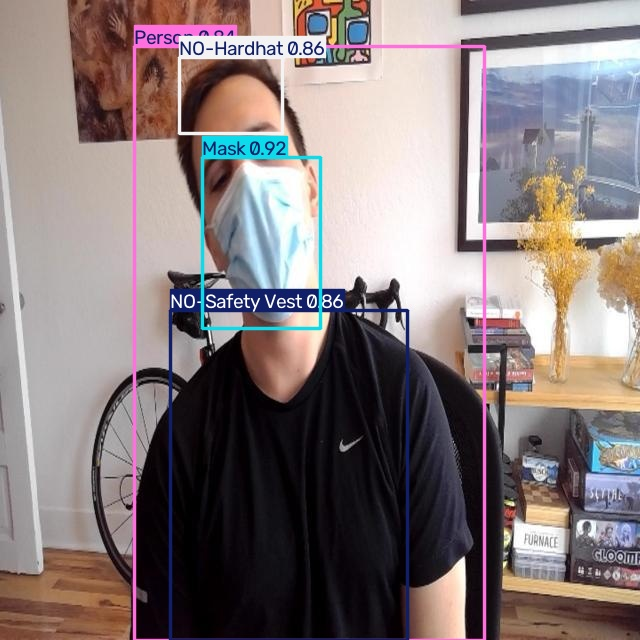

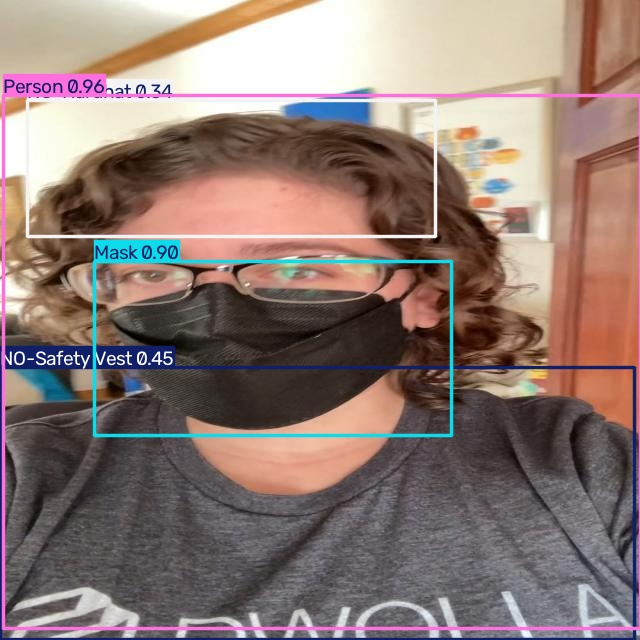

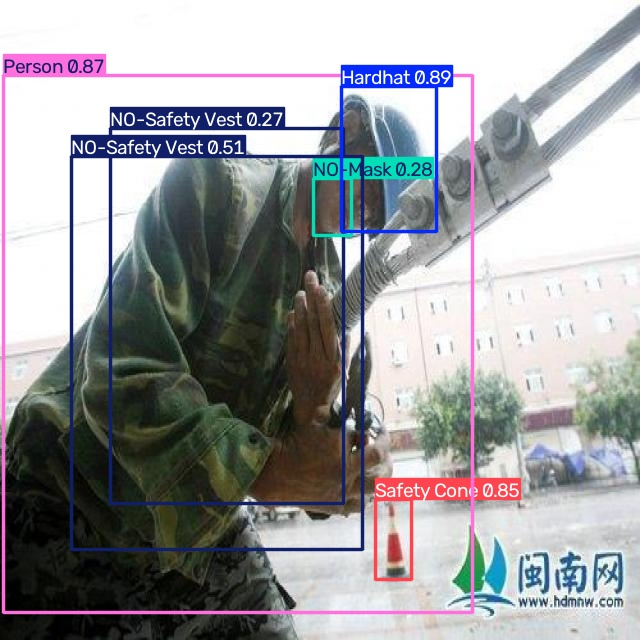

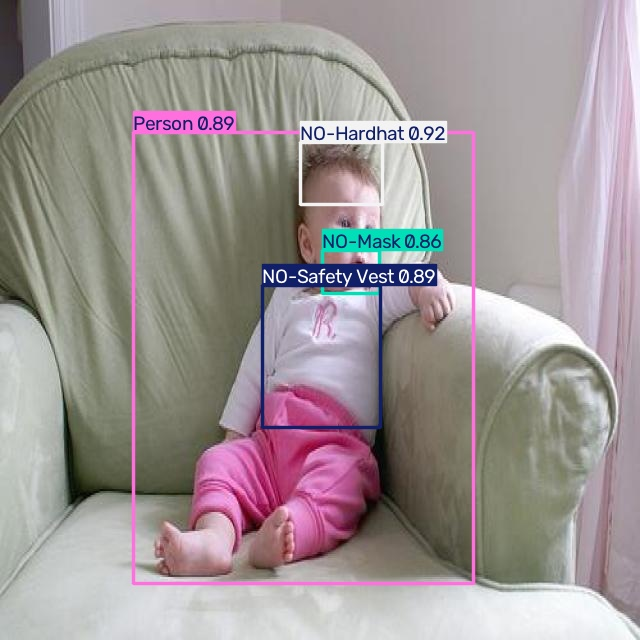

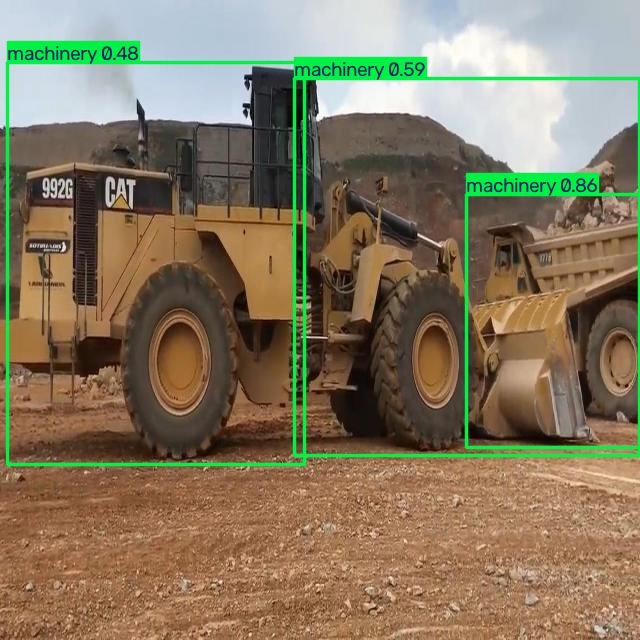

In [18]:
from IPython.display import Image, display

for img in predicted_images[:5]:
    display(Image(filename=img))

In [19]:
import os

results_dir = "/content/runs/construction_safety_yolo11n"

print(os.listdir(results_dir))

['val_batch2_labels.jpg', 'train_batch2.jpg', 'weights', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.csv', 'val_batch1_labels.jpg', 'val_batch2_pred.jpg', 'results.png', 'BoxR_curve.png', 'labels.jpg', 'BoxPR_curve.png', 'train_batch3260.jpg', 'val_batch1_pred.jpg', 'val_batch0_pred.jpg', 'train_batch0.jpg', 'val_batch0_labels.jpg', 'train_batch3262.jpg', 'train_batch1.jpg', 'BoxF1_curve.png', 'train_batch3261.jpg', 'BoxP_curve.png', 'args.yaml']


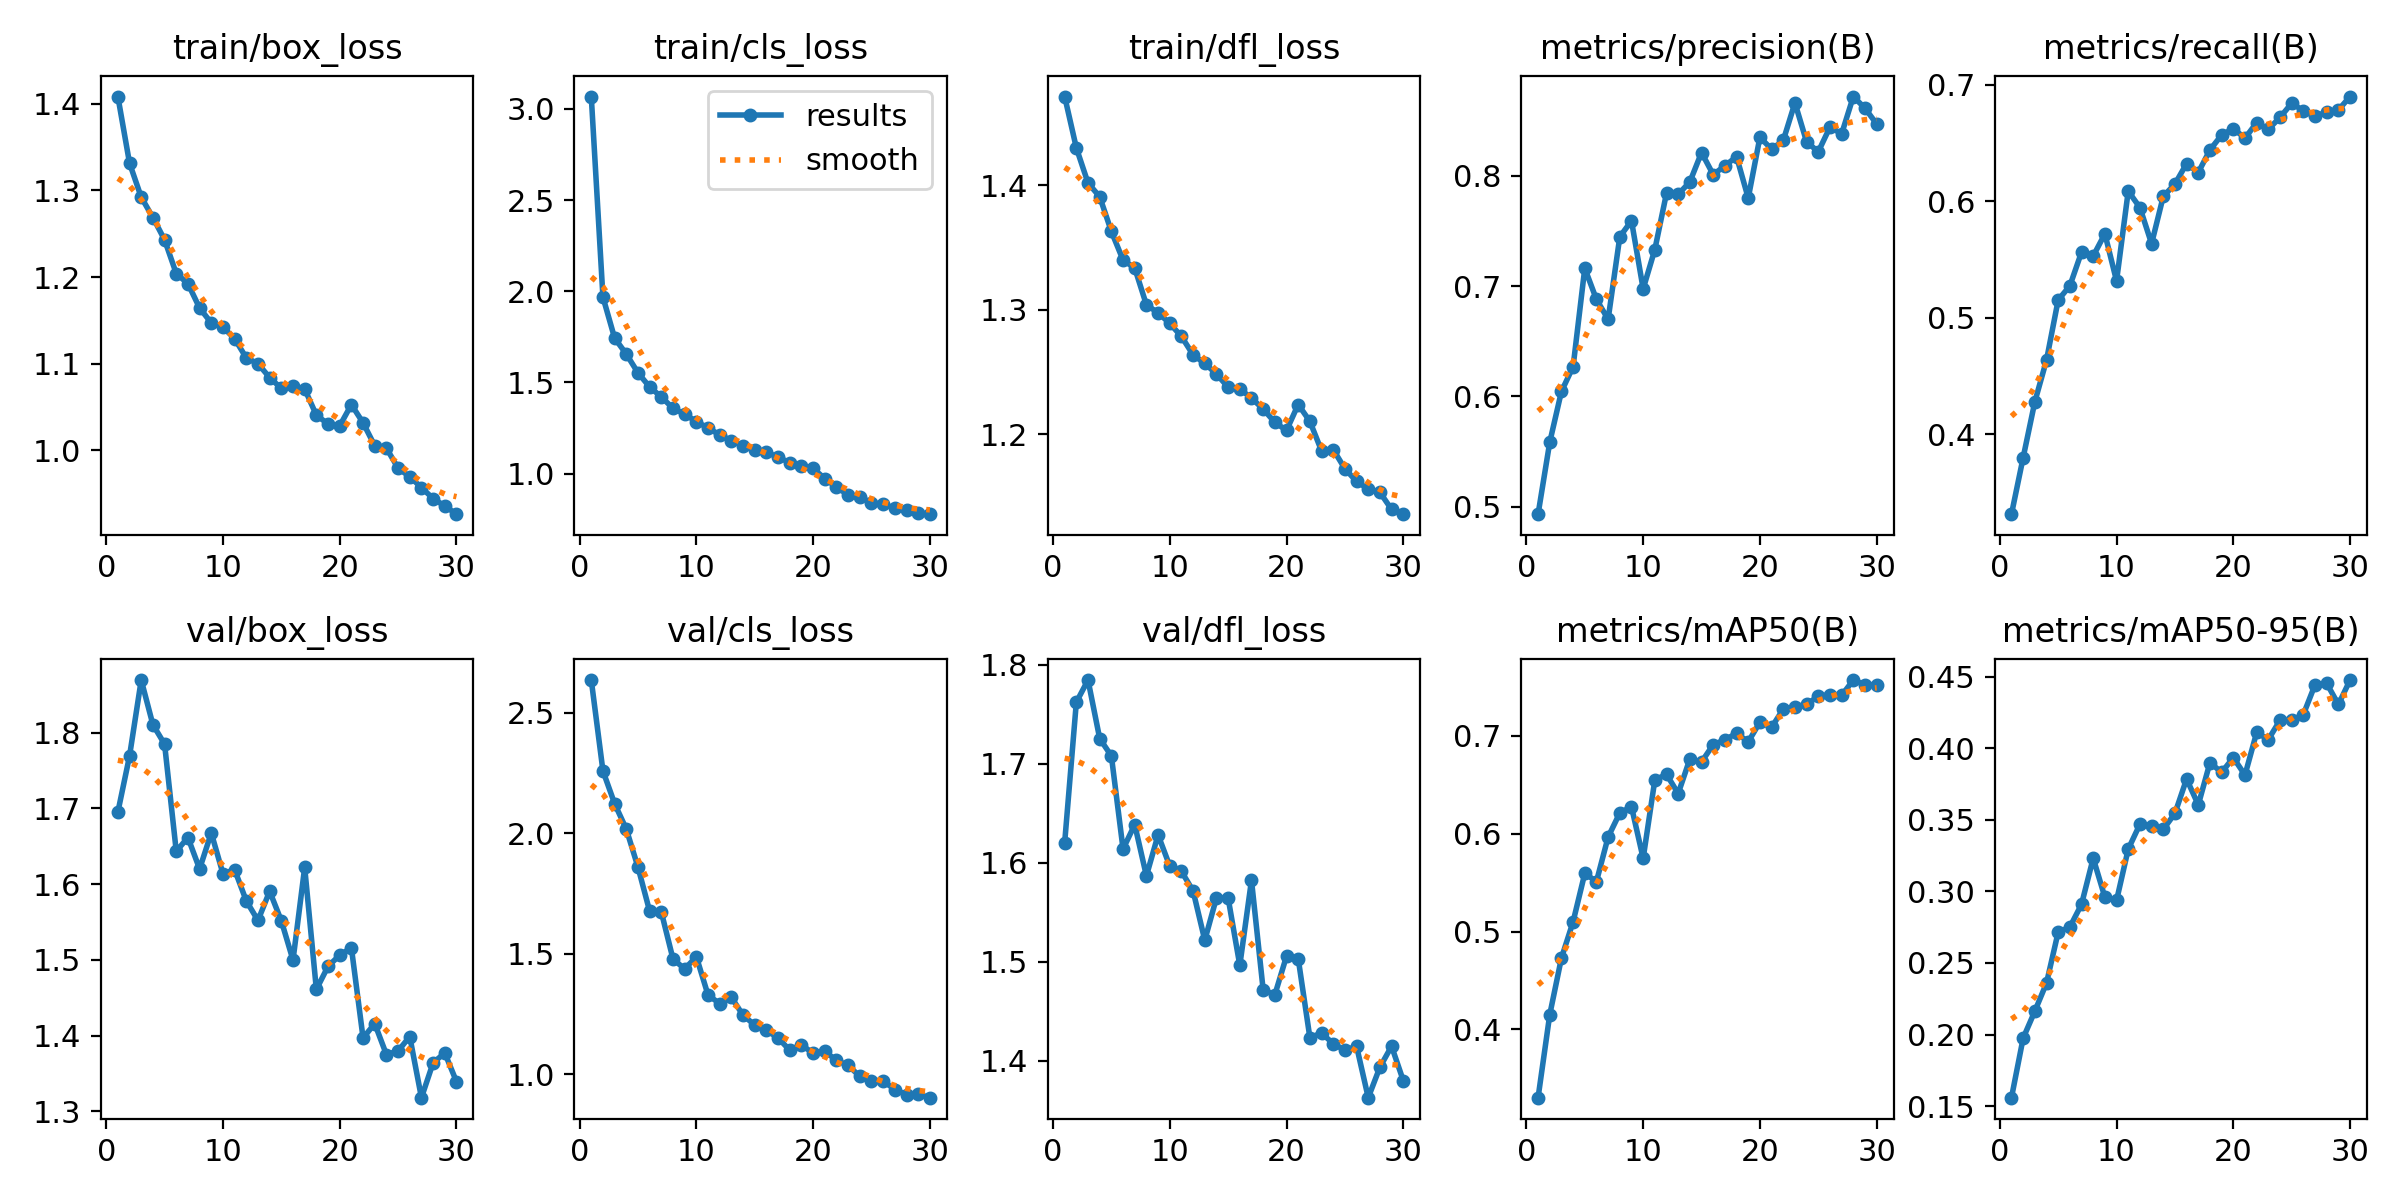

In [20]:
#Training results graph
from IPython.display import Image, display

display(Image(filename="/content/runs/construction_safety_yolo11n/results.png"))

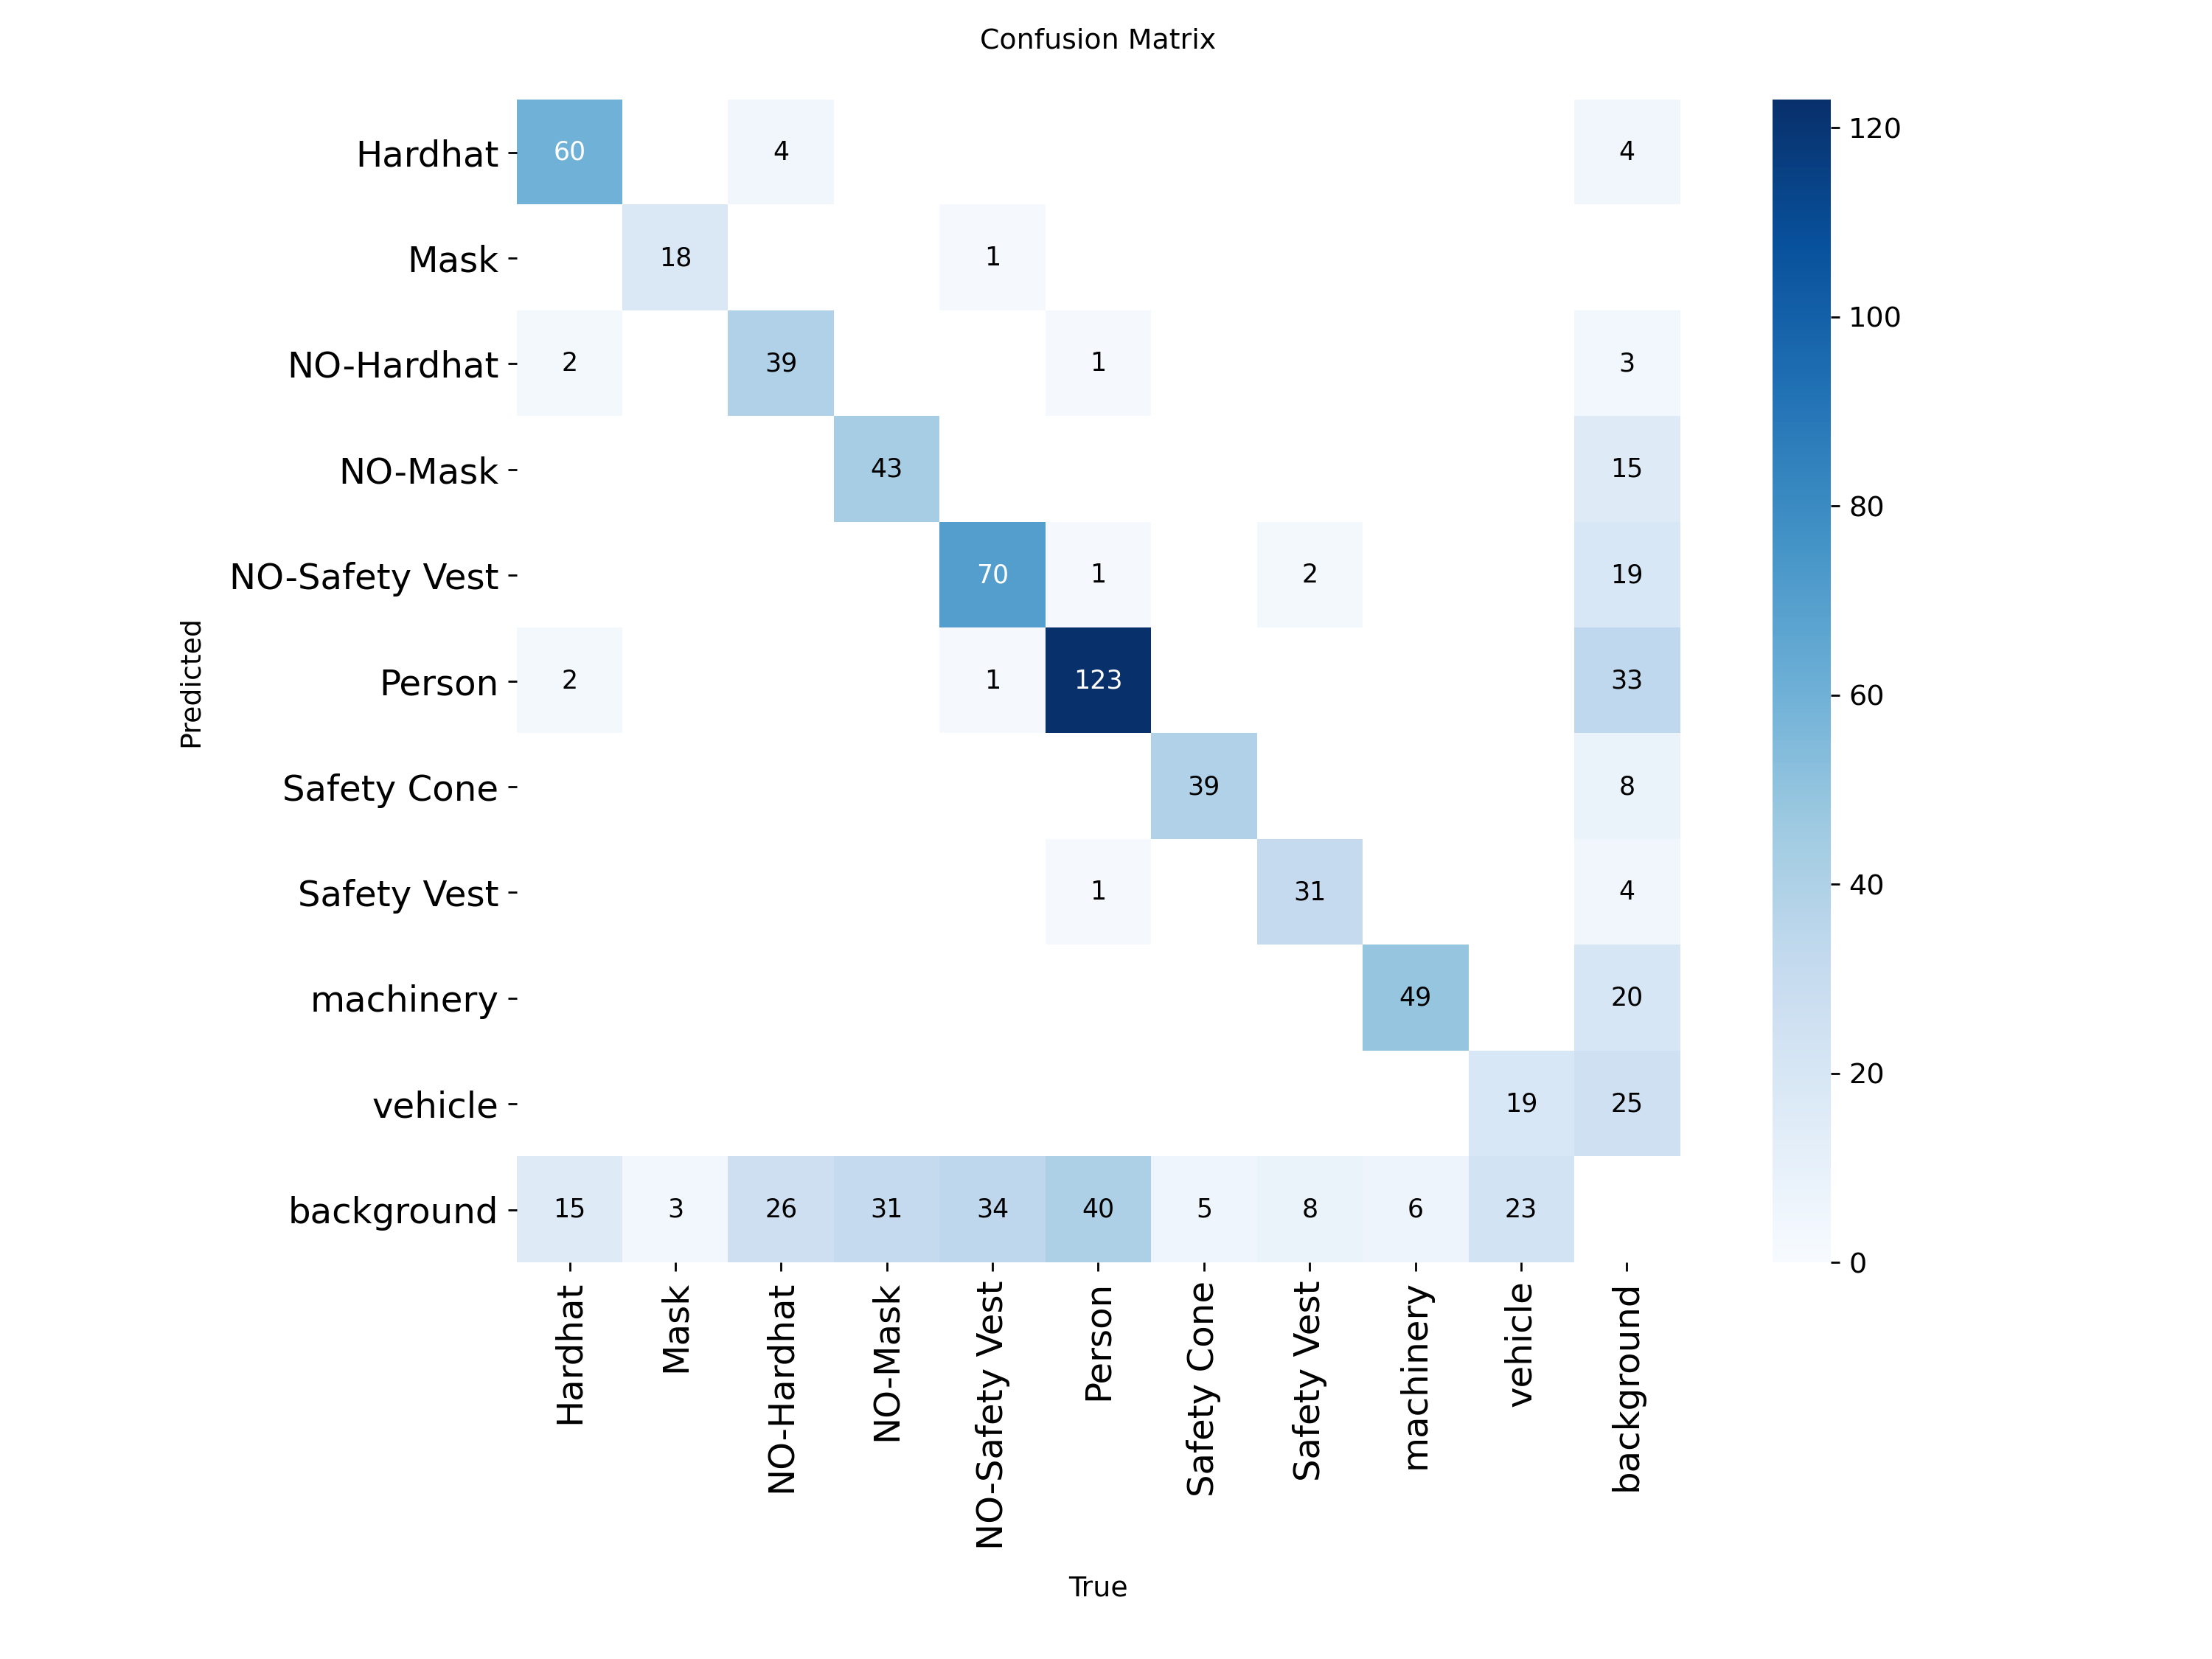

In [21]:
#Confusion matrix
display(Image(filename="/content/runs/construction_safety_yolo11n/confusion_matrix.png"))

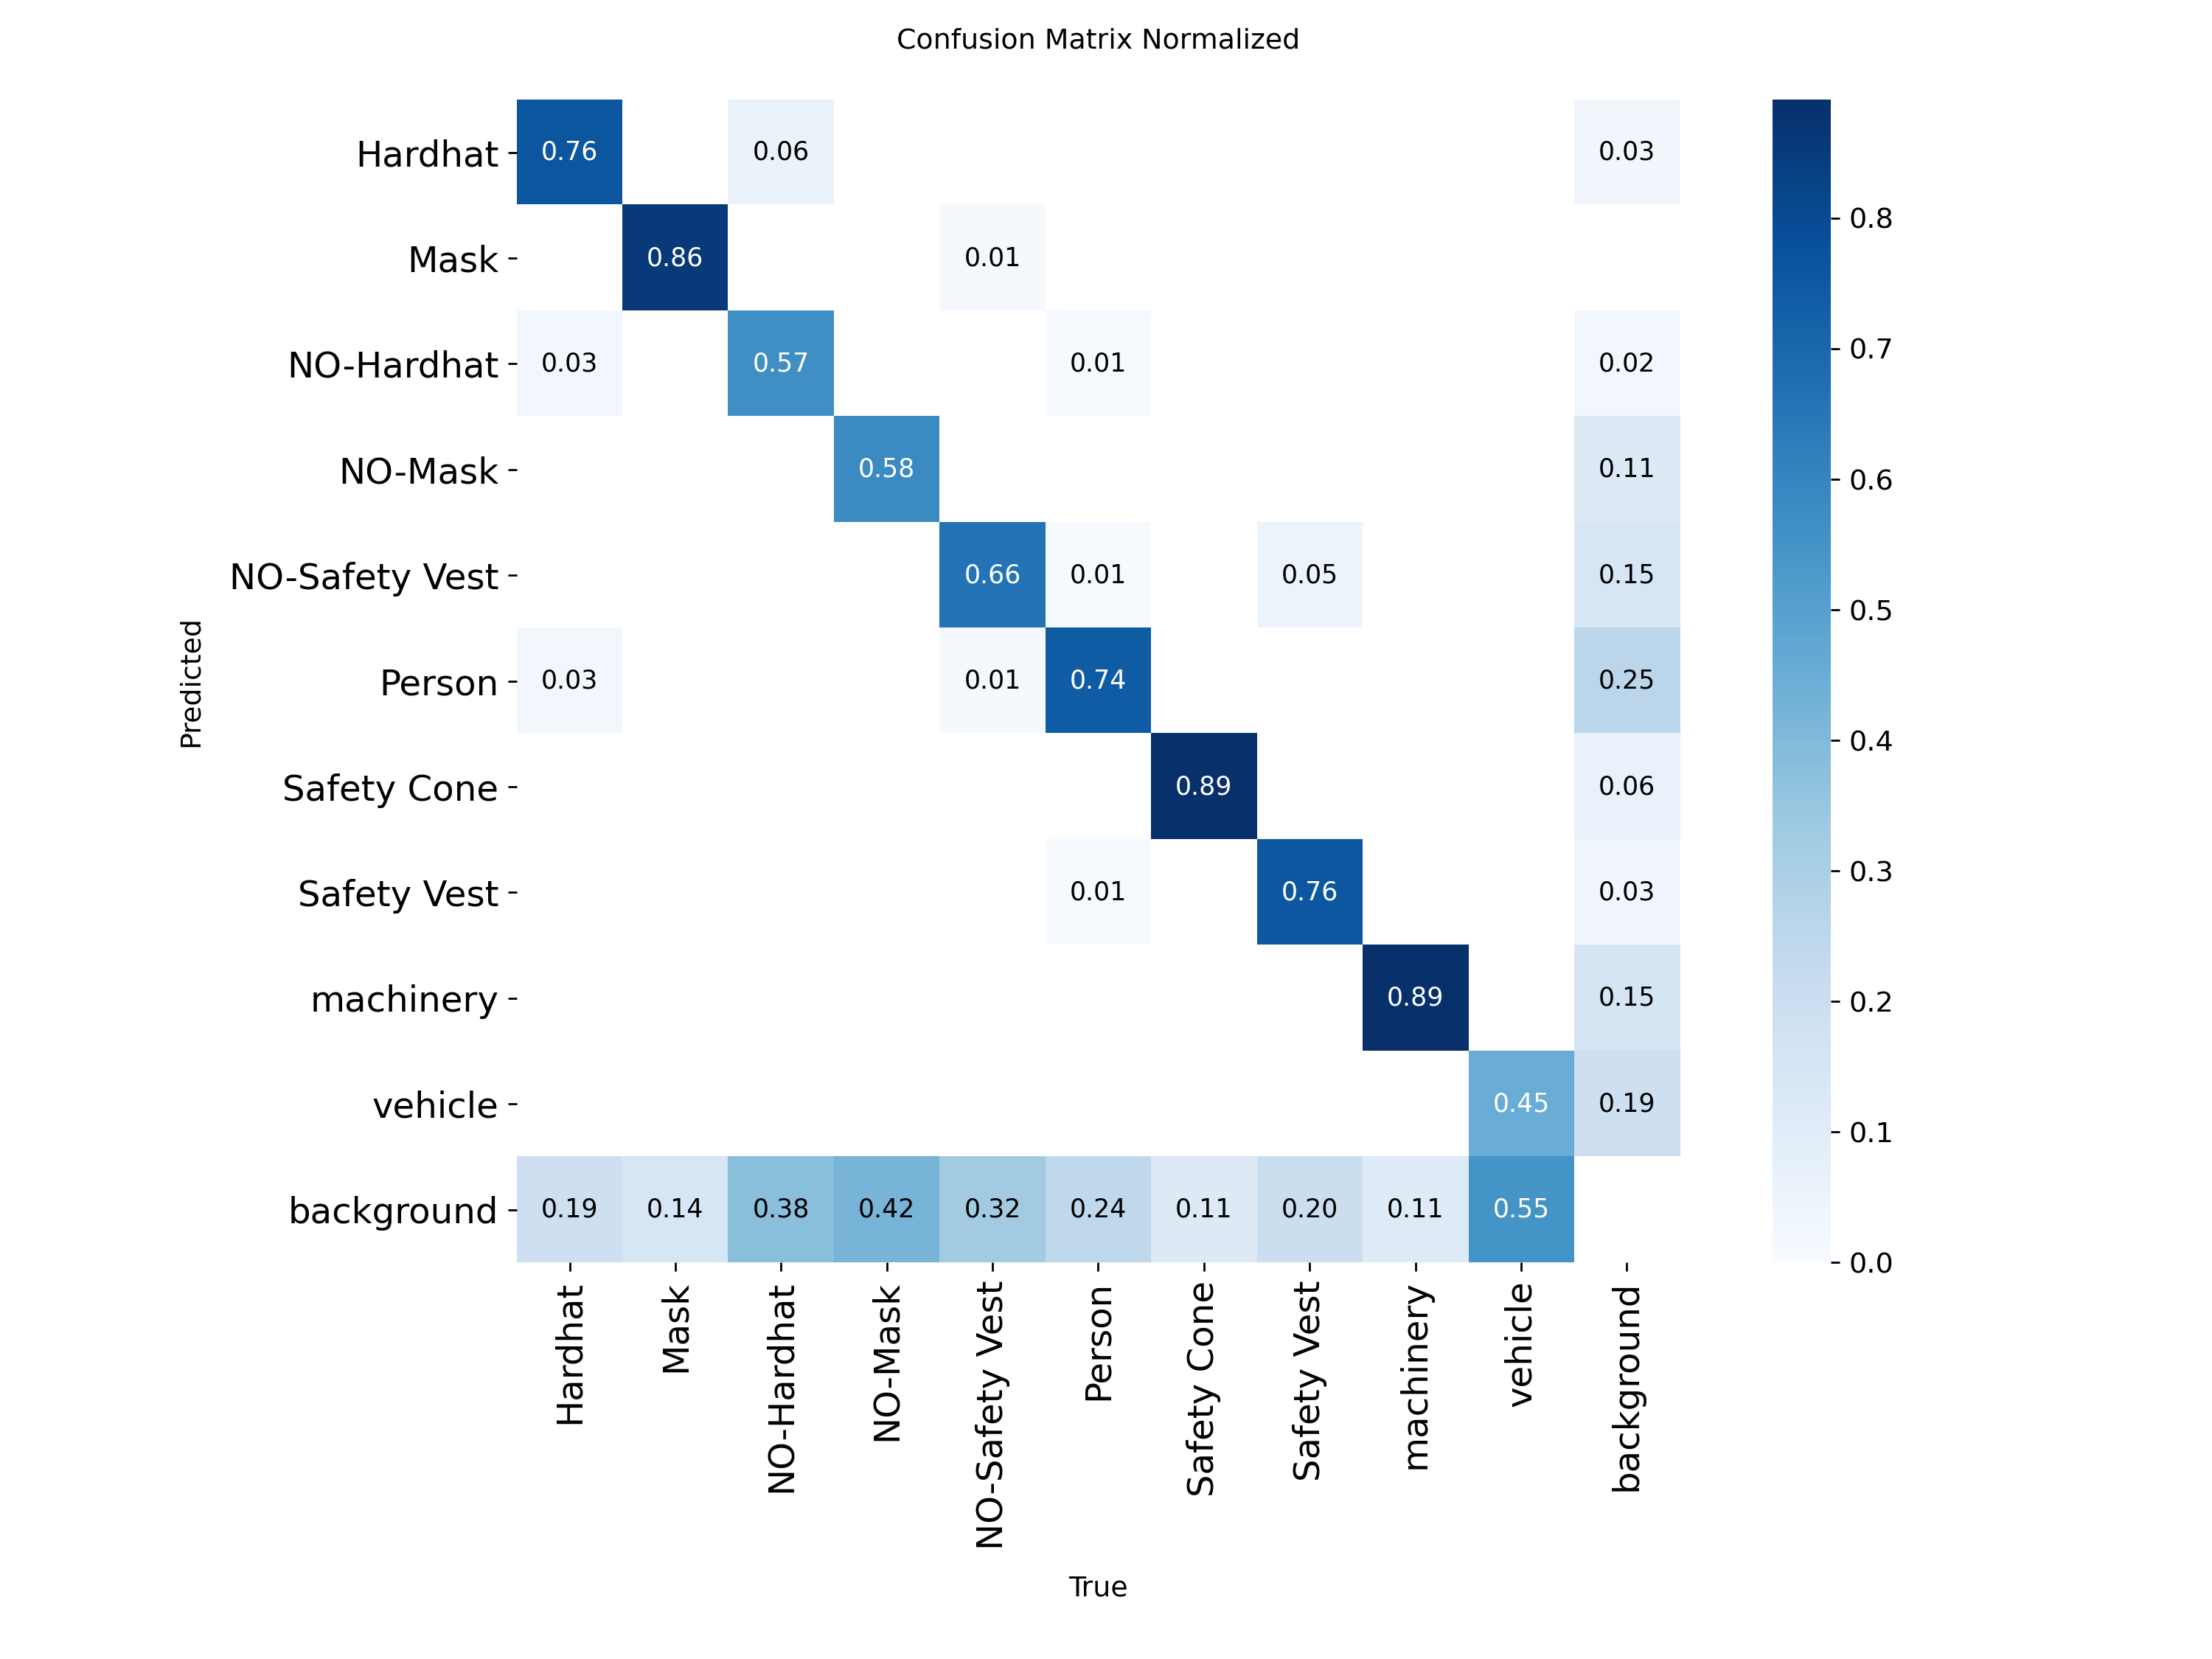

In [22]:
#Normalized confusion matrix
display(Image(filename="/content/runs/construction_safety_yolo11n/confusion_matrix_normalized.png"))

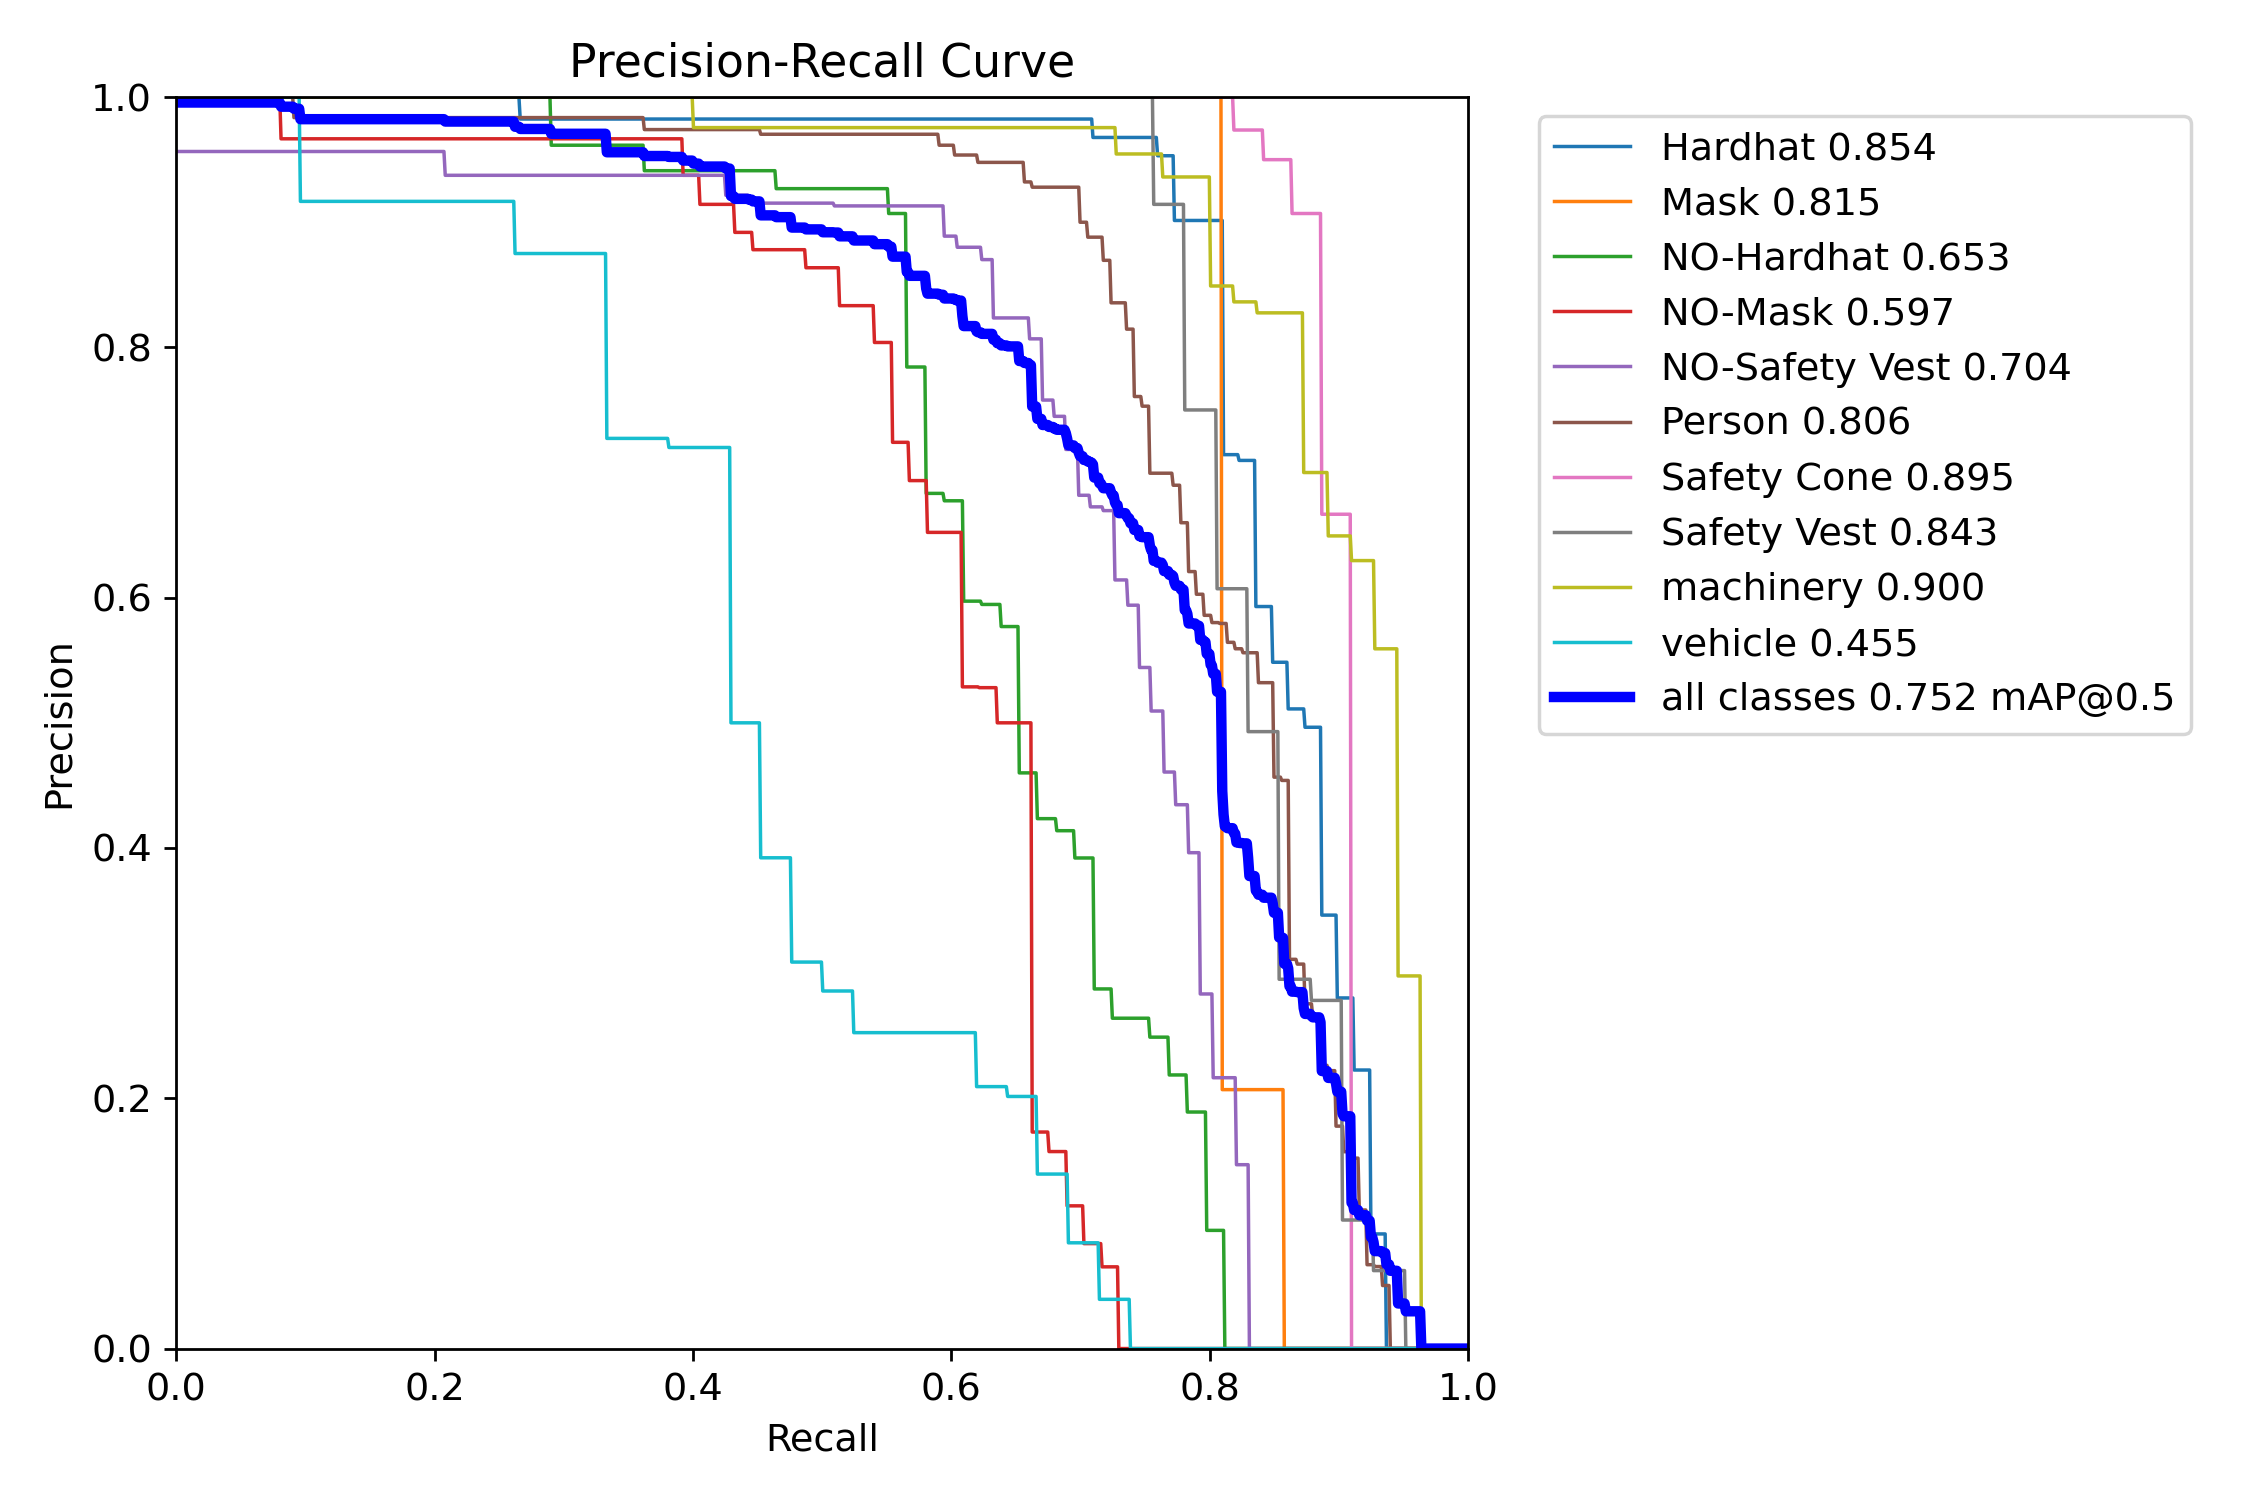

In [23]:
#Precision–Recall curve
display(Image(filename="/content/runs/construction_safety_yolo11n/BoxPR_curve.png"))

Number of prediction images: 74


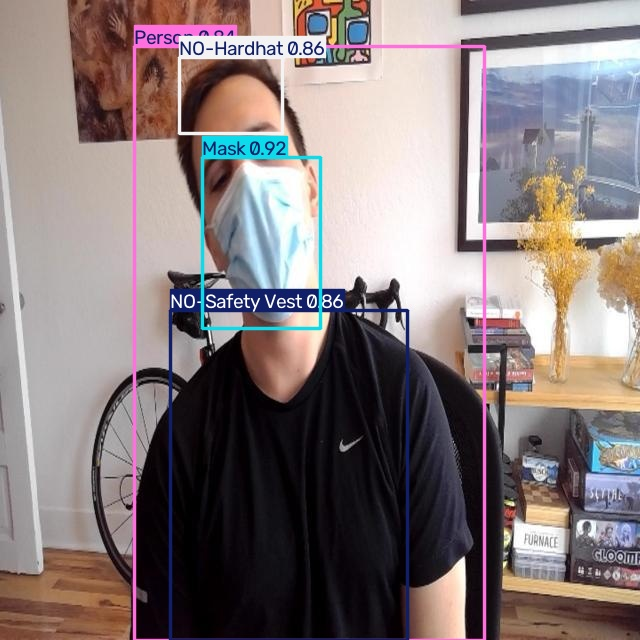

In [24]:
#actual prediction
import glob
from IPython.display import Image, display

pred_images = glob.glob("/content/runs/detect/predict/*.jpg")

print("Number of prediction images:", len(pred_images))

display(Image(filename=pred_images[0]))

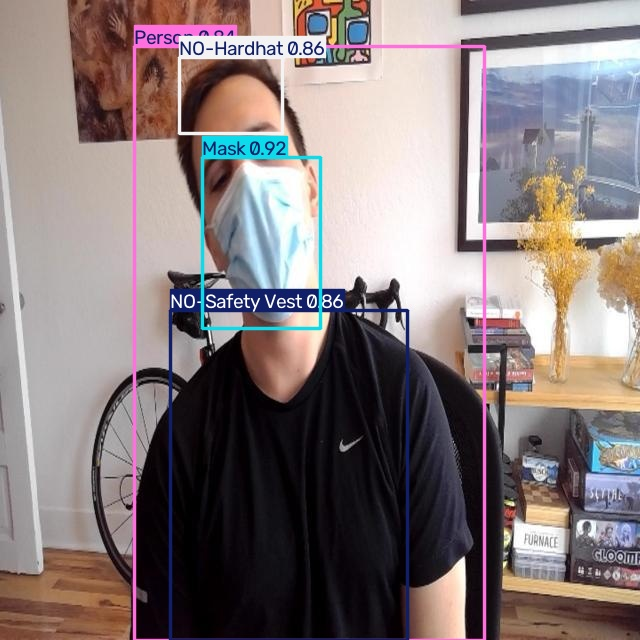

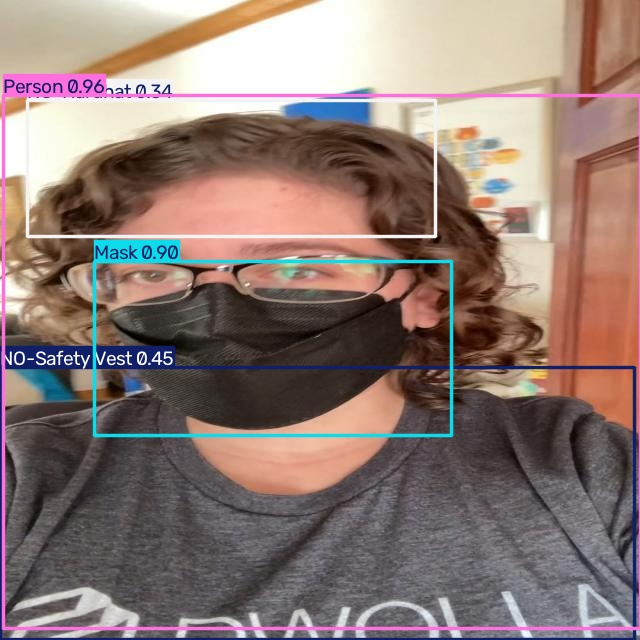

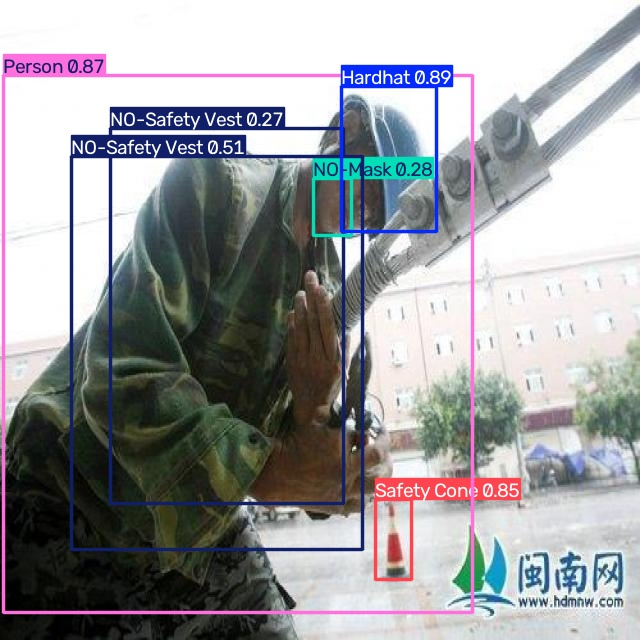

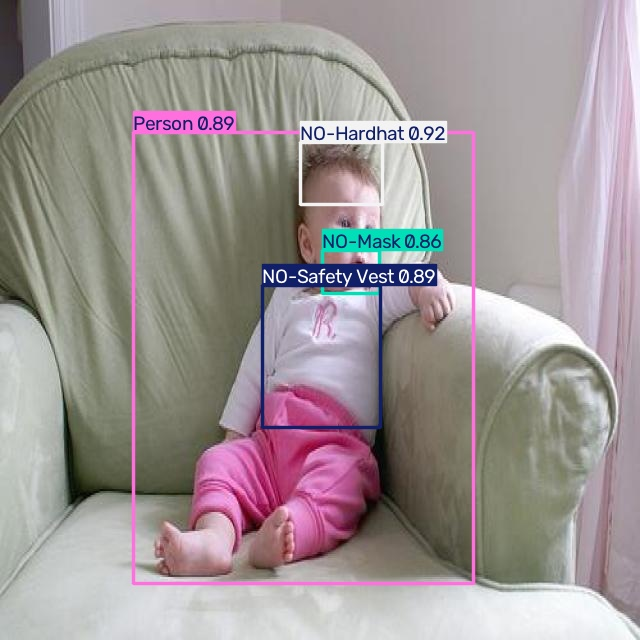

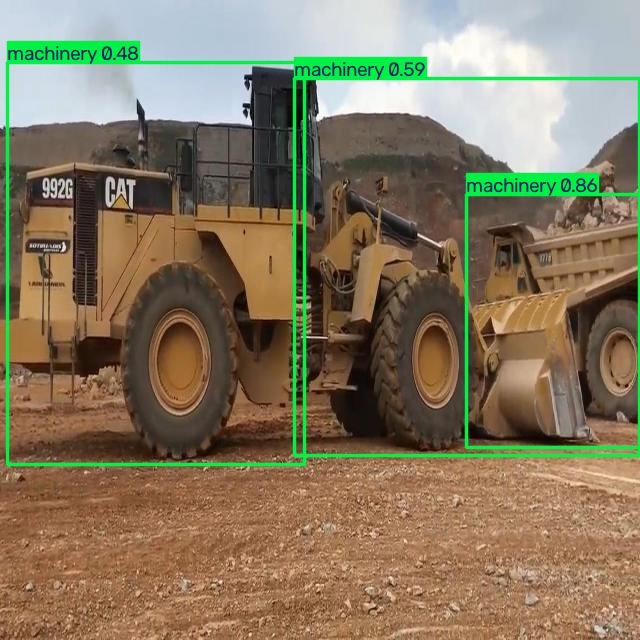

In [25]:
# Display multiple prediction examples

for img in pred_images[:5]:
    display(Image(filename=img))

In [26]:
# Final Test Results Summary

print("=" * 50)
print("CONSTRUCTION SITE SAFETY - YOLO11n")
print("FINAL TEST RESULTS")
print("=" * 50)

print(f"Test Images       : 74")
print(f"Precision         : 82.8%")
print(f"Recall            : 63.3%")
print(f"mAP@50            : 69.9%")
print(f"mAP@50-95         : 40.3%")

print("=" * 50)


CONSTRUCTION SITE SAFETY - YOLO11n
FINAL TEST RESULTS
Test Images       : 74
Precision         : 82.8%
Recall            : 63.3%
mAP@50            : 69.9%
mAP@50-95         : 40.3%


# Final Conclusion

## Construction Site Safety Monitoring Using YOLO11 Object Detection

This project developed an object detection system for construction-site
safety monitoring using the YOLO11n model.

The Construction Site Safety dataset was prepared using Roboflow, where
images were annotated with bounding boxes for the objects of interest.
The final Roboflow Version 1 dataset contained 2,777 images, with all
images annotated. The dataset was divided into:

- Training set: 2,599 images
- Validation set: 104 images
- Test set: 74 images

The dataset contains 10 object classes:

1. Hardhat
2. Mask
3. NO-Hardhat
4. NO-Mask
5. NO-Safety Vest
6. Person
7. Safety Cone
8. Safety Vest
9. machinery
10. vehicle

The Roboflow dataset was exported in YOLO format and used in Google
Colab for model training. The experiment was performed using an
NVIDIA Tesla T4 GPU.

The YOLO11n model was trained with the following configuration:

- Model: YOLO11n
- Image size: 640 × 640
- Epochs: 30
- Batch size: 16
- GPU: NVIDIA Tesla T4
- Training framework: Ultralytics YOLO
- Dataset format: YOLO
- Number of classes: 10

During training, the model learned to detect construction-site
objects and safety-related equipment from the annotated training
images. The best trained model was saved as `best.pt`.

The model was evaluated first on the validation dataset and then on
the separate test dataset. The final test evaluation was performed
using 74 previously separated test images containing 760 annotated
instances.

### Final Test Results

| Metric | Result |
|---|---:|
| Precision | **82.8%** |
| Recall | **63.3%** |
| mAP@50 | **69.9%** |
| mAP@50–95 | **40.3%** |

The model achieved a precision of 82.8%, indicating that a high
proportion of its predicted detections were correct. The recall of
63.3% indicates that the model successfully detected a substantial
portion of the objects present in the test images, although some
objects were missed.

The mAP@50 score of 69.9% represents the overall object-detection
performance at an IoU threshold of 0.50. The mAP@50–95 score of 40.3%
provides a stricter evaluation across multiple IoU thresholds.

The project also generated several evaluation and training outputs,
including:

- Training results graph
- Confusion matrix
- Normalized confusion matrix
- Precision-recall curve
- Precision curve
- Recall curve
- F1-score curve
- Dataset label distribution visualization
- Training batch visualizations
- Validation images with ground-truth labels
- Validation images with model predictions
- Test-set prediction images with detected bounding boxes

The prediction stage was performed on the test images using the
trained `best.pt` model. The generated prediction images provide
visual evidence of the model's ability to locate and classify
construction-site objects using bounding boxes.

Overall, the experiment demonstrates that YOLO11n can be used for
construction-site safety monitoring and can detect objects such as
hardhats, masks, safety vests, people, safety cones, machinery, and
vehicles. The obtained results provide a useful baseline for the
project.

The model's performance could potentially be improved in future work
by increasing the amount and diversity of training data, experimenting
with different YOLO model sizes, adjusting training parameters,
increasing the number of training epochs, and evaluating suitable
data-augmentation strategies.

The complete experimental notebook, configuration, evaluation
results, and selected prediction outputs are organized for
reproducibility and documentation.

In [29]:
import os

results_dir = "/content/runs/construction_safety_yolo11n"

print("Files in the training results folder:\n")

for file in os.listdir(results_dir):
    print(file)

Files in the training results folder:

val_batch2_labels.jpg
train_batch2.jpg
weights
confusion_matrix_normalized.png
confusion_matrix.png
results.csv
val_batch1_labels.jpg
val_batch2_pred.jpg
results.png
BoxR_curve.png
labels.jpg
BoxPR_curve.png
train_batch3260.jpg
val_batch1_pred.jpg
val_batch0_pred.jpg
train_batch0.jpg
val_batch0_labels.jpg
train_batch3262.jpg
train_batch1.jpg
BoxF1_curve.png
train_batch3261.jpg
BoxP_curve.png
args.yaml


In [30]:
import zipfile
import os

results_dir = "/content/runs/construction_safety_yolo11n"

files_to_save = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxPR_curve.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png",
    "labels.jpg",
    "results.csv",
    "val_batch0_labels.jpg",
    "val_batch1_labels.jpg",
    "val_batch2_labels.jpg",
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_pred.jpg"
]

zip_path = "/content/YOLO11_Final_Results.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for filename in files_to_save:
        filepath = os.path.join(results_dir, filename)

        if os.path.exists(filepath):
            zipf.write(filepath, arcname=filename)
            print("Added:", filename)
        else:
            print("Not found:", filename)

print("\nZIP created successfully:")
print(zip_path)

Added: results.png
Added: confusion_matrix.png
Added: confusion_matrix_normalized.png
Added: BoxPR_curve.png
Added: BoxP_curve.png
Added: BoxR_curve.png
Added: BoxF1_curve.png
Added: labels.jpg
Added: results.csv
Added: val_batch0_labels.jpg
Added: val_batch1_labels.jpg
Added: val_batch2_labels.jpg
Added: val_batch0_pred.jpg
Added: val_batch1_pred.jpg
Added: val_batch2_pred.jpg

ZIP created successfully:
/content/YOLO11_Final_Results.zip


In [31]:
from google.colab import files

files.download("/content/YOLO11_Final_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import glob

pred_images = glob.glob("/content/runs/detect/predict/*.jpg")

print("Number of prediction images:", len(pred_images))

Number of prediction images: 74


In [33]:
import glob
import os
import shutil

pred_images = sorted(
    glob.glob("/content/runs/detect/predict/*.jpg")
)

selected_dir = "/content/selected_predictions"
os.makedirs(selected_dir, exist_ok=True)

# Select 5 prediction images
selected_images = pred_images[:5]

for i, img_path in enumerate(selected_images, start=1):
    destination = os.path.join(
        selected_dir,
        f"prediction_{i:02d}.jpg"
    )
    shutil.copy(img_path, destination)
    print("Saved:", destination)

print("\nSelected", len(selected_images), "prediction images.")

Saved: /content/selected_predictions/prediction_01.jpg
Saved: /content/selected_predictions/prediction_02.jpg
Saved: /content/selected_predictions/prediction_03.jpg
Saved: /content/selected_predictions/prediction_04.jpg
Saved: /content/selected_predictions/prediction_05.jpg

Selected 5 prediction images.


In [34]:
import glob
import os
import shutil

pred_images = sorted(
    glob.glob("/content/runs/detect/predict/*.jpg")
)

selected_dir = "/content/selected_predictions"
os.makedirs(selected_dir, exist_ok=True)

# Select 5 prediction images
selected_images = pred_images[:5]

for i, img_path in enumerate(selected_images, start=1):
    destination = os.path.join(
        selected_dir,
        f"prediction_{i:02d}.jpg"
    )
    shutil.copy(img_path, destination)
    print("Saved:", destination)

print("\nSelected", len(selected_images), "prediction images.")

Saved: /content/selected_predictions/prediction_01.jpg
Saved: /content/selected_predictions/prediction_02.jpg
Saved: /content/selected_predictions/prediction_03.jpg
Saved: /content/selected_predictions/prediction_04.jpg
Saved: /content/selected_predictions/prediction_05.jpg

Selected 5 prediction images.


/content/selected_predictions/prediction_01.jpg


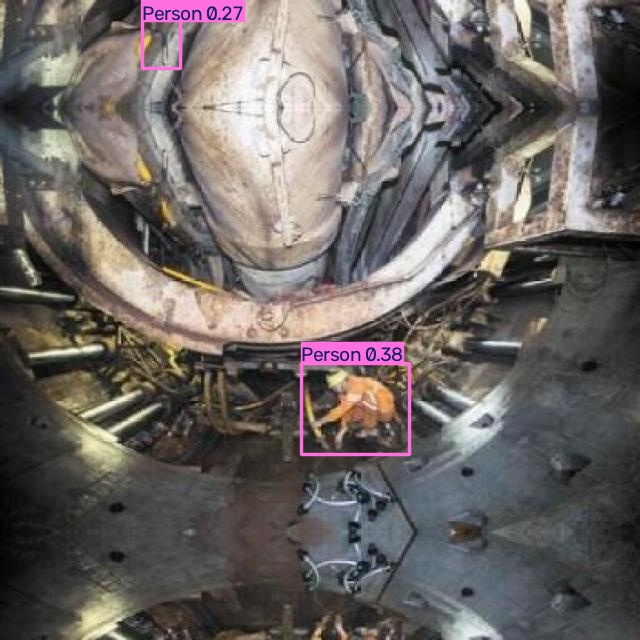

/content/selected_predictions/prediction_02.jpg


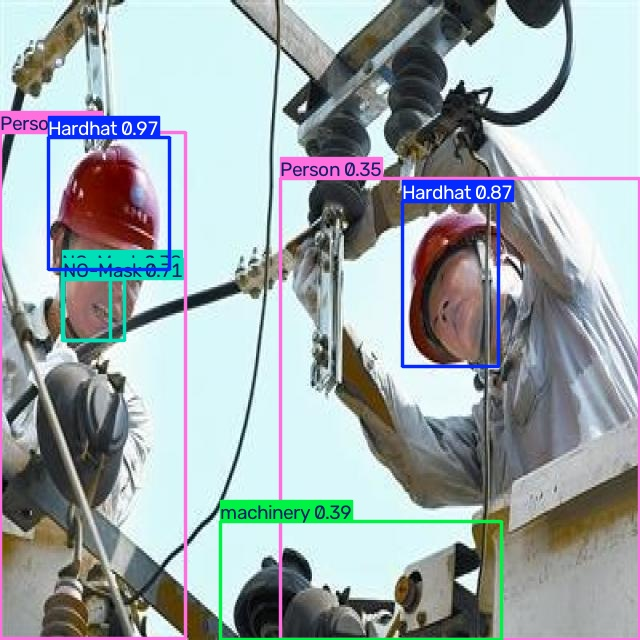

/content/selected_predictions/prediction_03.jpg


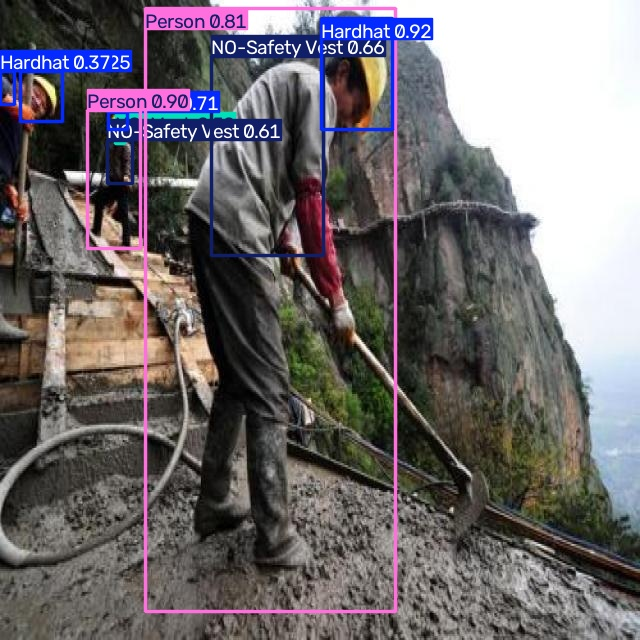

/content/selected_predictions/prediction_04.jpg


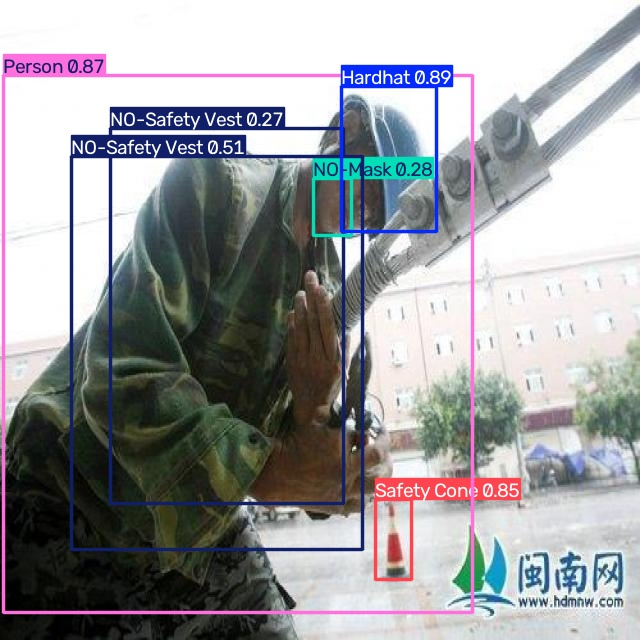

/content/selected_predictions/prediction_05.jpg


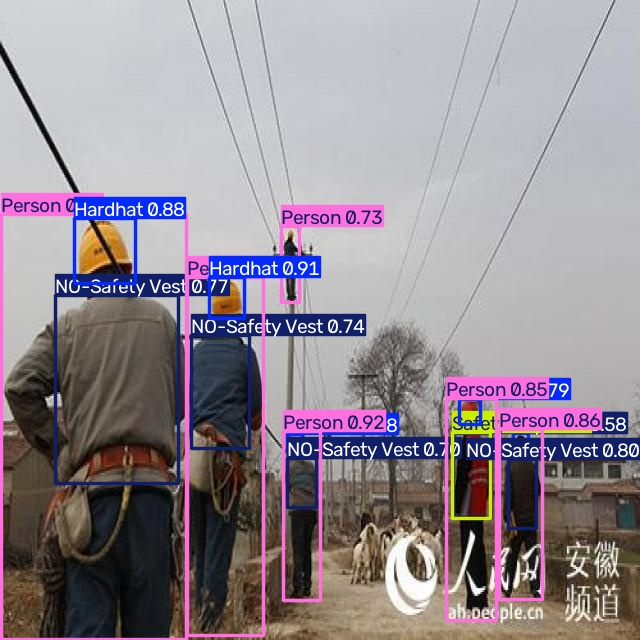

In [37]:
from IPython.display import Image, display
import glob

selected_images = sorted(
    glob.glob("/content/selected_predictions/*.jpg")
)

for img in selected_images:
    print(img)
    display(Image(filename=img))

In [38]:
import zipfile
import os

zip_path = "/content/YOLO11_Prediction_Examples.zip"

with zipfile.ZipFile(zip_path, "w") as zipf:
    for img_path in selected_images:
        zipf.write(
            img_path,
            arcname=os.path.basename(img_path)
        )

print("Created:", zip_path)

Created: /content/YOLO11_Prediction_Examples.zip


In [39]:
from google.colab import files

files.download("/content/YOLO11_Prediction_Examples.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>